# Hands-on: Constructive RL for JSSP with L2D


L2D learns a priority dispatching rule (PDR) that repeatedly selects an eligible operation. The two exercises implement its reward function and an optimal, one. the local action mask; the GNN, PPO setup, and evaluation are provided.

## Learning objectives

By the end, you should be able to:

- derive a reward function from the completion-time lower bounds;
- compare a learned PDR with SPT under the same schedule transition.

## 0. Setup

Run the following install and imports before starting the assignment.

In [18]:
!pip install -r requirements.txt

In [19]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from visualization import gantt_chart, precedence_chart
from solution_methods.helper_functions import load_job_shop_env, load_parameters
from solution_methods.L2D.network.actor_critic import ActorCritic
from solution_methods.L2D.src.JSSP_Env import SJSSP
from solution_methods.L2D.src.mb_agg import g_pool_cal
from solution_methods.L2D.training_data.instance_generator import uniform_instance_generator

In [20]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_JOBS, N_MACHINES = 6, 6
N_OPERATIONS = N_JOBS * N_MACHINES
LOW, HIGH = 1, 100  # HIGH is exclusive: processing times are 1,...,99.
SEED = 200

np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Device: {DEVICE}")

Device: cpu


## 1. Inspect a JSSP-6×6 instance

Let $\mathcal J$ be the jobs and $\mathcal M$ the machines. Operation $O_{ij}$ is job $i$'s $j$-th operation, with processing time $p_{ij}$, start time $S_{ij}$, and completion time $C_{ij}=S_{ij}+p_{ij}$. The objective is $C_{\max}=\max_{i,j}C_{ij}$.

The local L2D instance stores `(processing_times, machines)`, both with shape `(J, M)` and each job in order. Machine IDs are one-based here and zero-based in the benchmark `JobShop`.

In [21]:
l2d_instance, job_shop_env = uniform_instance_generator(
    N_JOBS, N_MACHINES, LOW, HIGH, seed=SEED, return_job_shop=True,
    instance_name="part4_l2d_uniform_6x6",
)
processing_times, machine_order = l2d_instance
print(job_shop_env)
print("Processing times:\n", processing_times)
print("One-based machine IDs:\n", machine_order)
assert np.all(np.sort(machine_order, axis=1) == np.arange(1, N_MACHINES + 1))

<JobShop(instance='part4_l2d_uniform_6x6', jobs=6, operations=36, machines=6)>
Processing times:
 [[27 17 69 43 56 77]
 [80 90 15 92 58 90]
 [12  7 43 57  2  8]
 [52 28 74 16  2 24]
 [86 25  8 23 55 78]
 [17 71 36 32 33 46]]
One-based machine IDs:
 [[6 4 1 3 5 2]
 [3 2 1 6 5 4]
 [2 5 1 6 3 4]
 [2 1 3 5 4 6]
 [1 4 3 5 6 2]
 [2 3 6 5 4 1]]


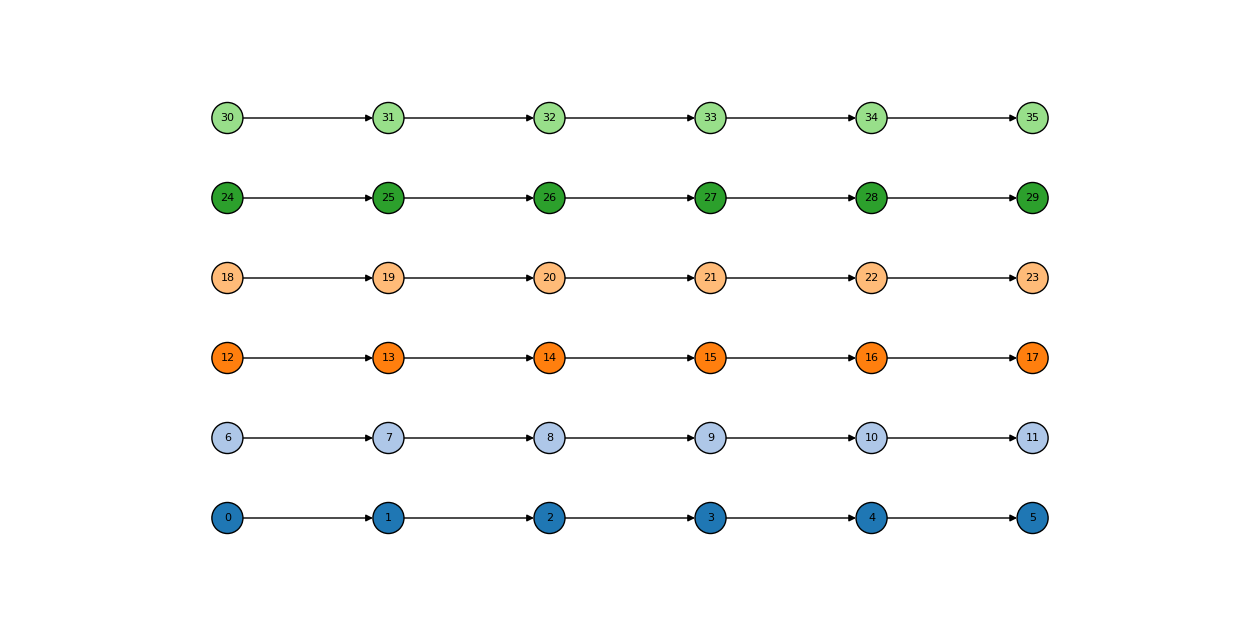

In [22]:
# Fixed job precedence before any machine order is selected.
precedence_chart.plot(job_shop_env)

## 2. MDP formulation of L2D

| MDP component | Notation and setup in L2D |
|---|---|
| State | $s_t$; graph plus node features, which is an indicator of the operation is scheduled and the lower-bound completion time of the operation. |
| Eligible actions | $A_t$: next unscheduled operation of each unfinished job |
| Action | schedule an eligible operation $a_t\in A_t$ |
| Transition | $s_t\to s_{t+1}$; inserts $a_t$, which is an operation |
| Reward | $R(a_t,s_t)=H(s_t)-H(s_{t+1})$ |
| Policy | $\pi_\theta(a_t\mid s_t)$ over $A_t$ |



In [23]:
parameters = load_parameters("configs/L2D.toml")
l2d_env = SJSSP(N_JOBS, N_MACHINES, parameters["env_parameters"])
adjacency, features, candidates, mask = l2d_env.reset(l2d_instance)

print("adjacency:", adjacency.shape)
print("operation features (CLB, I):", features.shape)
display(pd.DataFrame({
    "slot/job": np.arange(N_JOBS),
    "candidate operation": candidates,
    "operation in job": candidates % N_MACHINES,
    "masked": mask,
}))
np.testing.assert_array_equal(candidates, np.arange(0, N_OPERATIONS, N_MACHINES))
assert not parameters["env_parameters"]["normalize_reward_and_state"]
np.testing.assert_allclose(
    features[:, 0],
    l2d_env.LBs.reshape(-1) / parameters["env_parameters"]["et_normalize_coef"],
)
np.testing.assert_array_equal(features[:, 1], l2d_env.finished_mark.reshape(-1))
assert not mask.any()

adjacency: (36, 36)
operation features (CLB, I): (36, 2)


,slot/job,candidate operation,operation in job,masked
0,0,0,0,False
1,1,6,0,False
2,2,12,0,False
3,3,18,0,False
4,4,24,0,False
5,5,30,0,False


## 3. Exercise — Reward Function (15 minutes)

For transition $s_t\to s_{t+1}$ after dispatching $a_t$, implement

$$R(a_t,s_t)=H(s_t)-H(s_{t+1}), \qquad H(s)=\max_O \operatorname{CLB}(O,s),$$

where $\operatorname{CLB}(O,s)$ is the completion-time lower bound of operation $O$ in state $s$.

The positive cost increase is $H(s_{t+1})-H(s_t)$ and its negative is the reward. At the terminal state, $H(s_T)=C_{\max}$, $C_{\max}$ is the makespan (time to complete all operations). With $\gamma=1$,

$$C_{\max}=H(s_0)-\sum_{t=0}^{T-1}R(a_t,s_t).$$

Since $H(s_0)$ is fixed for an instance, maximizing cumulative reward minimizes makespan.

<details>
<summary>Answer</summary>

```python
def teaching_makespan_reward(h_s_t, h_s_next):
    """Return cost increase and R(a_t, s_t) for one or more transitions."""
    h_s_t = np.asarray(h_s_t, dtype=float)
    h_s_next = np.asarray(h_s_next, dtype=float)
    reward = -(h_s_next - h_s_t)

    return reward
```

</details>

In [ ]:
def teaching_makespan_reward(h_s_t, h_s_next):
    """Return cost increase and R(a_t, s_t) for one or more transitions."""
    h_s_t = np.asarray(h_s_t, dtype=float)
    h_s_next = np.asarray(h_s_next, dtype=float)
    # Calculate the reward based on the difference between each state.
    reward = ...
    
    return reward

### Test the reward
The following cell checks the rewards function on a toy trace and the environment of L2D.

In [27]:
trace = np.array([5.0, 7.0, 7.0, 10.0])
rewards = teaching_makespan_reward(trace[:-1], trace[1:])
np.testing.assert_allclose(-trace[0] + rewards.sum(), -trace[-1])
display(pd.DataFrame({"H before": trace[:-1], "H after": trace[1:], "reward": rewards}))

# Check the identity on a complete rollout in the real environment.
reward_env = SJSSP(N_JOBS, N_MACHINES, parameters["env_parameters"])
_, _, reward_candidates, reward_mask = reward_env.reset(l2d_instance)
initial_bound = float(reward_env.max_endTime)
total_reward = 0.0
while not reward_env.done():
    slot = int(np.flatnonzero(~reward_mask)[0])
    previous_bound = float(reward_env.max_endTime)
    _, _, reward, _, reward_candidates, reward_mask = reward_env.step(
        int(reward_candidates[slot])
    )
    expected_reward = teaching_makespan_reward(
        previous_bound, float(reward_env.max_endTime)
    )
    np.testing.assert_allclose(reward, expected_reward)
    total_reward += float(reward)
np.testing.assert_allclose(-initial_bound + total_reward, -reward_env.max_endTime)
print(f"Initial bound {initial_bound:.0f}; final makespan {reward_env.max_endTime:.0f}")

,H before,H after,reward
0,5.0,7.0,-2.0
1,7.0,7.0,-0.0
2,7.0,10.0,-3.0


Initial bound 425; final makespan 606


## 4. Network Setup of L2D

After $K$ GIN iterations, every operation has embedding $h_O^{(K)}(s_t)$. Average pooling produces graph embedding $h_G(s_t)$. For each eligible operation $a\in A_t$, the actor scores $[h_a^{(K)}(s_t),h_G(s_t)]$ and softmax produces $\pi_\theta(a\mid s_t)$. Training samples from this distribution; during evaluation, the action with the highest probability is selected.


In [28]:
def build_l2d_policy(n_jobs, n_machines, device):
    net = parameters["network_parameters"]
    return ActorCritic(
        n_j=n_jobs, n_m=n_machines, num_layers=net["num_layers"],
        learn_eps=False, neighbor_pooling_type=net["neighbor_pooling_type"],
        input_dim=net["input_dim"], hidden_dim=net["hidden_dim"],
        num_mlp_layers_feature_extract=net["num_mlp_layers_feature_extract"],
        num_mlp_layers_actor=net["num_mlp_layers_actor"],
        hidden_dim_actor=net["hidden_dim_actor"],
        num_mlp_layers_critic=net["num_mlp_layers_critic"],
        hidden_dim_critic=net["hidden_dim_critic"], device=device,
    ).to(device)

policy_env = SJSSP(N_JOBS, N_MACHINES, parameters["env_parameters"])
policy_adj, policy_features, policy_candidates, policy_mask = policy_env.reset(l2d_instance)
for _ in range(N_MACHINES):
    policy_adj, policy_features, _, _, policy_candidates, policy_mask = policy_env.step(
        int(policy_candidates[0])
    )

untrained_policy = build_l2d_policy(N_JOBS, N_MACHINES, DEVICE).eval()
graph_pool = g_pool_cal(parameters["network_parameters"]["graph_pool_type"],
                        torch.Size([1, N_OPERATIONS, N_OPERATIONS]),
                        N_OPERATIONS, DEVICE)
with torch.inference_mode():
    pi, value = untrained_policy(
        x=torch.from_numpy(policy_features.copy()).to(DEVICE),
        graph_pool=graph_pool, padded_nei=None,
        adj=torch.from_numpy(policy_adj.copy()).to(DEVICE).to_sparse(),
        candidate=torch.from_numpy(policy_candidates.copy()).to(DEVICE).unsqueeze(0),
        mask=torch.from_numpy(policy_mask.copy()).to(DEVICE).unsqueeze(0),
    )
slot_probabilities = pi.squeeze(-1)
assert torch.all(slot_probabilities[0, torch.from_numpy(policy_mask).to(DEVICE)] == 0)
torch.testing.assert_close(slot_probabilities.sum(1), torch.ones(1, device=DEVICE))
slot = int(slot_probabilities.argmax(1))
print(f"slot {slot} -> operation {policy_candidates[slot]}; value {value.item():.3f}")

slot 2 -> operation 12; value 0.019


## 5. Optional short PPO training

Enable the provided cell below only to demonstrate the pipeline. One hundred updates are not enough to train a converged policy. The local categorical distribution samples a candidate slot and stores that slot for PPO's log-probability.


In [29]:
RUN_SHORT_TRAINING = False
SHORT_TRAINING_CHECKPOINT = Path("saved_models") / "6_6_1_100.pth"

if RUN_SHORT_TRAINING:
    training_parameters = load_parameters("configs/L2D.toml")
    if training_parameters["env_parameters"]["device"] != "cpu":
        raise ValueError("optional training expects env_parameters.device = 'cpu'")
    training_parameters["env_parameters"].update(
        {"n_j": 6, "n_m": 6, "low": 1, "high": 100}
    )
    training_parameters["train_parameters"].update(
        {"num_envs": 4, "max_updates": 100}
    )
    training_parameters["test_parameters"].update({"device": "cpu", "seed": SEED})
    from solution_methods.L2D.train_L2D import train_L2D
    train_L2D(**training_parameters)
else:
    print("Training skipped; the supplied checkpoint is used below.")

Training skipped; the supplied checkpoint is used below.


## 7. Evaluate and visualize a trained policy

L2D makespan: 528.0


,step,slot/job,operation,probability
0,1,4,24,0.172280
1,2,1,6,0.171946
2,3,1,7,0.173304
3,4,1,8,0.199660
4,5,4,25,0.174222


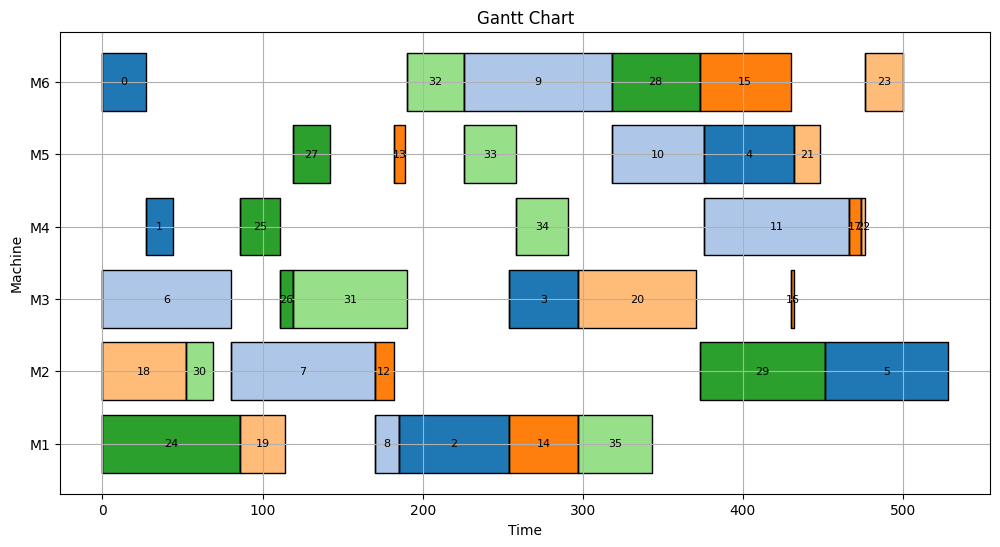

In [30]:
def job_shop_to_l2d(job_shop):
    durations = np.array([
        [next(iter(op.processing_times.values())) for op in job.operations]
        for job in job_shop.jobs
    ], dtype=np.single)
    machines = np.array([
        [next(iter(op.processing_times.keys())) + 1 for op in job.operations]
        for job in job_shop.jobs
    ], dtype=np.int64)
    return durations, machines


def replay_actions(job_shop, actions):
    job_shop.reset()
    for action in actions:
        job_shop.update_operations_available_for_scheduling()
        operation = job_shop.get_operation(action)
        assert operation in job_shop.operations_available_for_scheduling
        machine, duration = next(iter(operation.processing_times.items()))
        job_shop.schedule_operation_with_backfilling(operation, machine, duration)
    return job_shop


@torch.inference_mode()
def greedy_l2d_rollout(instance, policy, device):
    n_jobs, n_machines = instance[0].shape
    n_nodes = n_jobs * n_machines
    env = SJSSP(n_jobs, n_machines, parameters["env_parameters"])
    pool = g_pool_cal(parameters["network_parameters"]["graph_pool_type"],
                      torch.Size([1, n_nodes, n_nodes]), n_nodes, device)
    adj, features, candidates, mask = env.reset(instance)
    actions, rows = [], []
    while not env.done():
        assert not mask.all()
        pi, _ = policy(
            x=torch.from_numpy(features.copy()).to(device), graph_pool=pool,
            padded_nei=None, adj=torch.from_numpy(adj.copy()).to(device).to_sparse(),
            candidate=torch.from_numpy(candidates.copy()).to(device).unsqueeze(0),
            mask=torch.from_numpy(mask.copy()).to(device).unsqueeze(0),
        )
        probabilities = pi.squeeze()
        slot = int(probabilities.argmax())
        action = int(candidates[slot])
        actions.append(action)
        rows.append({"step": len(actions), "slot/job": slot,
                     "operation": action, "probability": float(probabilities[slot])})
        adj, features, _, _, candidates, mask = env.step(action)
    return float(env.max_endTime), actions, pd.DataFrame(rows)


BUNDLED_CHECKPOINT = Path("solution_methods/L2D/saved_models/6_6_1_99.pth")
L2D_CHECKPOINT = SHORT_TRAINING_CHECKPOINT if RUN_SHORT_TRAINING else BUNDLED_CHECKPOINT
trained_policy = build_l2d_policy(N_JOBS, N_MACHINES, DEVICE).eval()
trained_policy.load_state_dict(torch.load(L2D_CHECKPOINT, map_location=DEVICE, weights_only=True))
makespan, actions, decision_trace = greedy_l2d_rollout(l2d_instance, trained_policy, DEVICE)
scheduled_job_shop = replay_actions(job_shop_env, actions)
np.testing.assert_allclose(scheduled_job_shop.makespan, makespan)
print("L2D makespan:", makespan)
display(decision_trace.head())
gantt_chart.plot(scheduled_job_shop);

## 8. Exploration — learned dispatching versus dispatching rules (5 minutes)

Compare L2D with **Shortest Processing Time (SPT)**, a manual PDR that chooses the eligible operation with smallest $p_{ij}$.

We evaluate Taillard `ta11` through `ta20` (20×15). The 6×6 checkpoint can run because the policy network is size-agnostic.

In [31]:
from solution_methods.L2D.evaluate_L2D import (
    FIRST_TEN_TAILLARD_INSTANCES, make_makespan_table, summarize_evaluation,
)


def spt_rollout(instance):
    durations = instance[0].reshape(-1)
    n_jobs, n_machines = instance[0].shape
    env = SJSSP(n_jobs, n_machines, parameters["env_parameters"])
    _, _, candidates, mask = env.reset(instance)
    while not env.done():
        eligible_slots = [int(slot) for slot in np.flatnonzero(~mask)]
        # Manual SPT PDR: smallest p_ij, then operation ID for deterministic ties.
        slot = min(eligible_slots, key=lambda s: (durations[candidates[s]], candidates[s]))
        _, _, _, _, candidates, mask = env.step(int(candidates[slot]))
    return float(env.max_endTime)


BENCHMARK_DEVICE = torch.device("cpu")


def evaluate_l2d_against_spt(instances, checkpoint):
    instance_data = [
        (Path(name).name, job_shop_to_l2d(load_job_shop_env(name)))
        for name in instances
    ]
    dimensions = instance_data[0][1][0].shape
    if any(instance[0].shape != dimensions for _, instance in instance_data):
        raise ValueError("all benchmark instances must have the same dimensions")

    policy = build_l2d_policy(*dimensions, BENCHMARK_DEVICE).eval()
    weights = torch.load(
        checkpoint, map_location=BENCHMARK_DEVICE, weights_only=True
    )
    policy.load_state_dict(weights)
    rows = []
    for label, instance in instance_data:
        start = perf_counter()
        l2d_makespan, _, _ = greedy_l2d_rollout(
            instance, policy, BENCHMARK_DEVICE
        )
        l2d_time = perf_counter() - start

        start = perf_counter()
        spt_makespan = spt_rollout(instance)
        spt_time = perf_counter() - start
        rows.extend([
            {"instance": label, "method": "L2D", "makespan": l2d_makespan,
             "runtime_seconds": l2d_time},
            {"instance": label, "method": "SPT", "makespan": spt_makespan,
             "runtime_seconds": spt_time},
        ])
        print(f"{label}: L2D={l2d_makespan:.0f}, SPT={spt_makespan:.0f}")
    return pd.DataFrame(rows)

In [32]:
RUN_TAILLARD_BENCHMARK = True
EVALUATION_CSV = Path("results/l2d_spt_taillard_comparison.csv")

if RUN_TAILLARD_BENCHMARK:
    evaluation_results = evaluate_l2d_against_spt(
        FIRST_TEN_TAILLARD_INSTANCES, L2D_CHECKPOINT
    )
    EVALUATION_CSV.parent.mkdir(parents=True, exist_ok=True)
    evaluation_results.to_csv(EVALUATION_CSV, index=False)
elif EVALUATION_CSV.exists():
    evaluation_results = pd.read_csv(EVALUATION_CSV)
else:
    raise FileNotFoundError("run the benchmark once or provide cached results")
assert set(evaluation_results["method"]) == {"L2D", "SPT"}

ta11: L2D=1867, SPT=2282
ta12: L2D=1806, SPT=2290
ta13: L2D=1774, SPT=2198
ta14: L2D=1796, SPT=2184
ta15: L2D=1884, SPT=2163
ta16: L2D=1795, SPT=2407
ta17: L2D=2050, SPT=2254
ta18: L2D=1806, SPT=2160
ta19: L2D=1779, SPT=2238
ta20: L2D=1955, SPT=2171


### Quality and runtime

The table highlights the lower makespan per instance. `wins` counts instances where each PDR attains the best makespan; ties count for both.

method,L2D,SPT
instance,,
ta11,1867.0,2282.0
ta12,1806.0,2290.0
ta13,1774.0,2198.0
ta14,1796.0,2184.0
ta15,1884.0,2163.0
ta16,1795.0,2407.0
ta17,2050.0,2254.0
ta18,1806.0,2160.0
ta19,1779.0,2238.0


,mean_makespan,median_makespan,mean_rank,wins,mean_runtime_seconds
method,,,,,
L2D,1851.2,1806.0,1.00,10,0.371
SPT,2234.7,2218.0,2.00,0,0.026


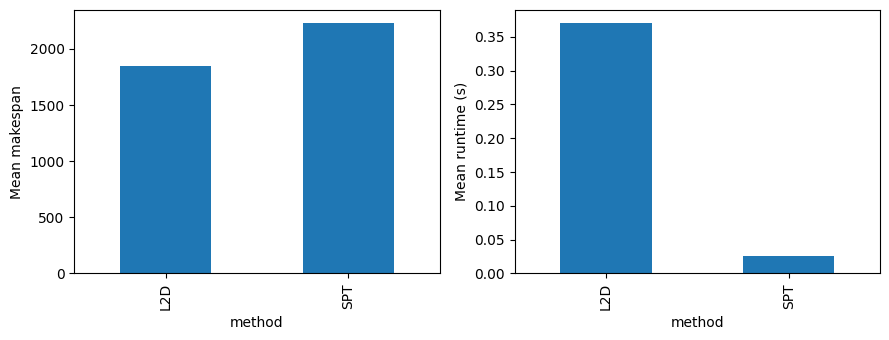

In [33]:
makespan_table = make_makespan_table(evaluation_results)
display(makespan_table.style.highlight_min(axis=1, color="lightgreen").format("{:.1f}"))

summary = summarize_evaluation(evaluation_results)
display(summary.style.format({
    "mean_makespan": "{:.1f}", "median_makespan": "{:.1f}",
    "mean_rank": "{:.2f}", "wins": "{:.0f}",
    "mean_runtime_seconds": "{:.3f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
summary["mean_makespan"].plot.bar(ax=axes[0], ylabel="Mean makespan")
summary["mean_runtime_seconds"].plot.bar(ax=axes[1], ylabel="Mean runtime (s)")
fig.tight_layout()

## Takeaways

- L2D learns a PDR that outperforms SPT on the Taillard benchmark.
- L2D is size-agnostic and can be applied to larger instances than those used in training.
- $R(a_t,s_t)=H(s_t)-H(s_{t+1})$ results in a reward function that focuses on the makespan objective.

## Sources and further reading

- [Learning to Dispatch](https://arxiv.org/abs/2010.12367)
- [The Job Shop Environment used in this tutorial](https://github.com/ai-for-decision-making-tue/Job_Shop_Scheduling_Benchmark_Environments_and_Instances)
- [Offline RL for JSSP](https://arxiv.org/abs/2409.10589)
- [Learning both JSSP and FJSP from solely random examples](https://arxiv.org/abs/2509.10303)
